# Ovarian Tumor DL + XAI
Complete pipeline comparing Baseline EfficientNet-B4 against EfficientNet-B4 + CBAM.

Dataset Distribution:
 - complex_cyst: 1368 images
 - dominant_follicle: 1297 images
 - healthy: 1465 images
 - poly_cyst: 1423 images
 - simple_cyst: 1326 images
Total: 6879 images



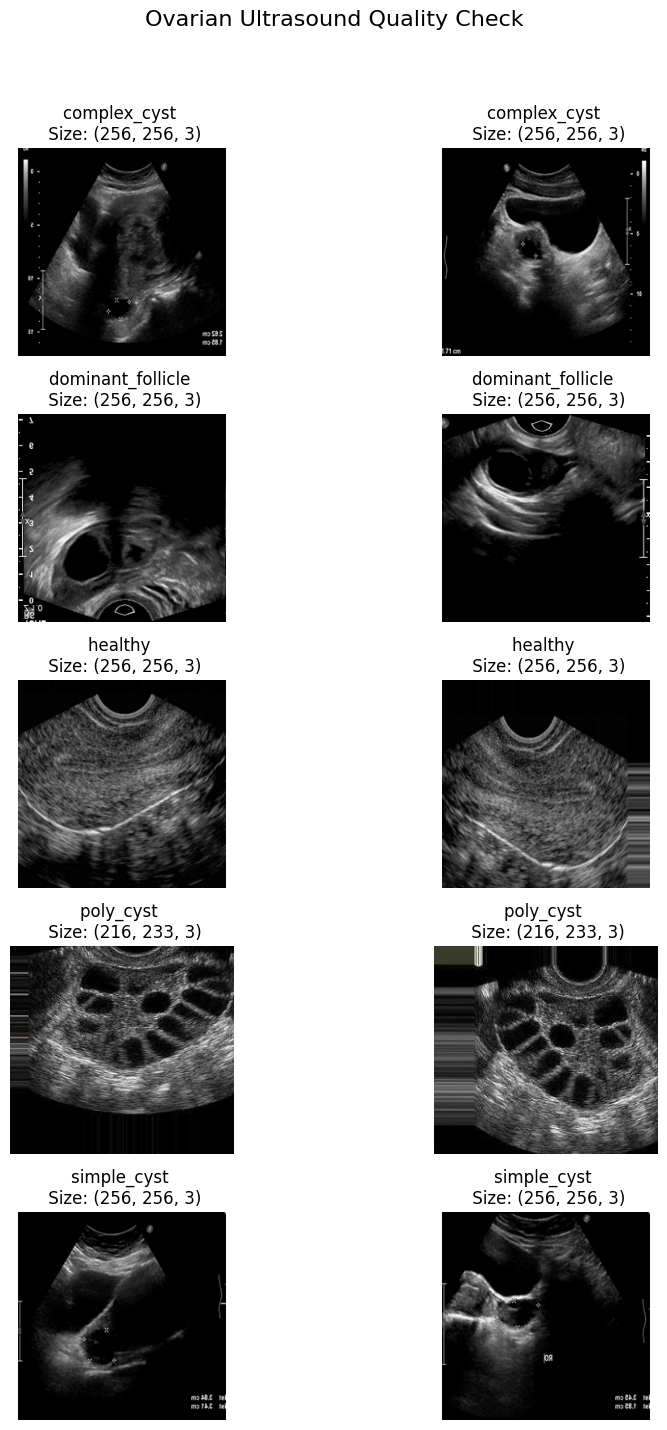

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the base directory for the dataset
base_dir = '/kaggle/input/datasets/ucimachinelearning/ovarian-ultrasound-image-dataset/Ovarian_US'

# The 5 classes
classes = ['complex_cyst', 'dominant_follicle', 'healthy', 'poly_cyst', 'simple_cyst']

# 1. Count and Verify
print("Dataset Distribution:")
total_images = 0
for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    num_files = len(os.listdir(cls_path))
    total_images += num_files
    print(f" - {cls}: {num_files} images")
print(f"Total: {total_images} images\n")

# 2. Visualize a Random Sample (2 images per class)
fig, axes = plt.subplots(5, 2, figsize=(10, 15))
fig.suptitle('Ovarian Ultrasound Quality Check', fontsize=16)

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    # Get all image files in the class
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    # Pick 2 random images
    random_samples = random.sample(images, 2)
    
    for j, img_name in enumerate(random_samples):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        
        ax = axes[i, j]
        ax.imshow(img, cmap='gray') # Grayscale for ultrasound
        ax.set_title(f"{cls} \n Size: {img.shape}")
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [5]:
!pip install efficientnet_pytorch grad-cam lime scikit-learn seaborn matplotlib torchinfo

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=3e587bef3d7400788eda14178a30939c89df0ae78414274fb92c98205e9531ba
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=65d01451133a5ca71a27fff6ddbd8efc0089c25f06ea91a02216eb7e41bcab8c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built efficientnet_pytorch grad-cam


In [6]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
base_dir = '/kaggle/input/datasets/ucimachinelearning/ovarian-ultrasound-image-dataset/Ovarian_US'
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=base_dir, transform=train_transforms)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

dataset_size = len(full_dataset)
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_split, val_split = int(0.70 * dataset_size), int(0.85 * dataset_size)
train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
test_sampler = SubsetRandomSampler(test_idx)

# DataLoaders
train_loader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=2)
clean_dataset = datasets.ImageFolder(root=base_dir, transform=test_transforms)
val_loader = DataLoader(clean_dataset, batch_size=batch_size, sampler=val_sampler, num_workers=2)
test_loader = DataLoader(clean_dataset, batch_size=batch_size, sampler=test_sampler, num_workers=2)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Classes: ['complex_cyst', 'dominant_follicle', 'healthy', 'poly_cyst', 'simple_cyst']
Train: 4813 | Val: 1031 | Test: 1032


In [8]:
# --- Attention Layers ---
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x_cat))

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x

# --- Models ---
class EfficientNetBaseline(nn.Module):
    def __init__(self, num_classes=5):
        super(EfficientNetBaseline, self).__init__()
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        
        # Freeze the pretrained backbone weights
        for param in self.backbone.features.parameters():
            param.requires_grad = False
            
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

class EfficientNetCBAM(nn.Module):
    def __init__(self, num_classes=5):
        super(EfficientNetCBAM, self).__init__()
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        
        # Freeze the pretrained backbone weights
        for param in self.backbone.features.parameters():
            param.requires_grad = False
            
        in_features = self.backbone.classifier[1].in_features 
        self.features = self.backbone.features
        self.cbam = CBAM(in_planes=in_features)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x) 
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model_baseline = EfficientNetBaseline(num_classes=num_classes).to(device)
model_cbam = EfficientNetCBAM(num_classes=num_classes).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 178MB/s] 


In [9]:
EPOCHS = 15

def train_model(model, name):
    print(f"\n--- Training {name} ---")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    
    for epoch in range(EPOCHS):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss, running_corrects = 0.0, 0
            
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            if phase == 'train':
                scheduler.step()
                
            epoch_loss = running_loss / len(dataloader.sampler)
            epoch_acc = running_corrects.double() / len(dataloader.sampler)
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            if phase == 'val':
                print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_acc:.4f} | Val Loss: {epoch_loss:.4f}")
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    
    model.load_state_dict(best_wts)
    print(f"-> Best {name} Val Acc: {best_acc:.4f}")
    return history, best_acc.item()

# Train Both architectures
history_base, val_acc_base = train_model(model_baseline, "EfficientNet-B4 (No Attention)")
history_cbam, val_acc_cbam = train_model(model_cbam, "EfficientNet-B4 + CBAM (Attention)")


--- Training EfficientNet-B4 (No Attention) ---
Epoch 1/15 | Val Acc: 0.9156 | Val Loss: 0.3270
Epoch 2/15 | Val Acc: 0.9447 | Val Loss: 0.2335
Epoch 3/15 | Val Acc: 0.9515 | Val Loss: 0.1988
Epoch 4/15 | Val Acc: 0.9505 | Val Loss: 0.1785
Epoch 5/15 | Val Acc: 0.9544 | Val Loss: 0.1645
Epoch 6/15 | Val Acc: 0.9534 | Val Loss: 0.1586
Epoch 7/15 | Val Acc: 0.9515 | Val Loss: 0.2124
Epoch 8/15 | Val Acc: 0.9602 | Val Loss: 0.1469
Epoch 9/15 | Val Acc: 0.9544 | Val Loss: 0.1422
Epoch 10/15 | Val Acc: 0.9564 | Val Loss: 0.1392
Epoch 11/15 | Val Acc: 0.9544 | Val Loss: 0.1350
Epoch 12/15 | Val Acc: 0.9602 | Val Loss: 0.1332
Epoch 13/15 | Val Acc: 0.9631 | Val Loss: 0.1329
Epoch 14/15 | Val Acc: 0.9544 | Val Loss: 0.1328
Epoch 15/15 | Val Acc: 0.9612 | Val Loss: 0.1357
-> Best EfficientNet-B4 (No Attention) Val Acc: 0.9631

--- Training EfficientNet-B4 + CBAM (Attention) ---
Epoch 1/15 | Val Acc: 0.9282 | Val Loss: 0.3839
Epoch 2/15 | Val Acc: 0.9370 | Val Loss: 0.2765
Epoch 3/15 | Val Acc:

ACCURACY COMPARISON (Before vs After Attention)
WITHOUT ATTENTION (Baseline):
 - Train Acc: 0.9150
 - Val   Acc: 0.9631
 - Test  Acc: 0.9457

WITH CBAM ATTENTION:
 - Train Acc: 0.9127
 - Val   Acc: 0.9602
 - Test  Acc: 0.9390


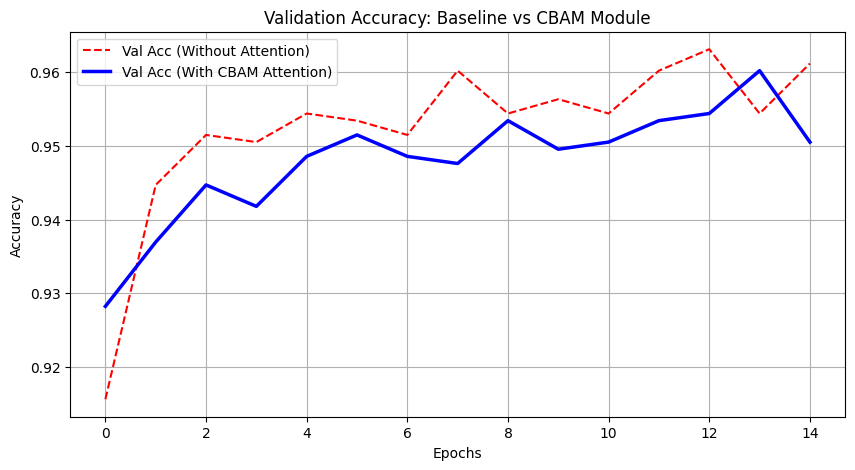

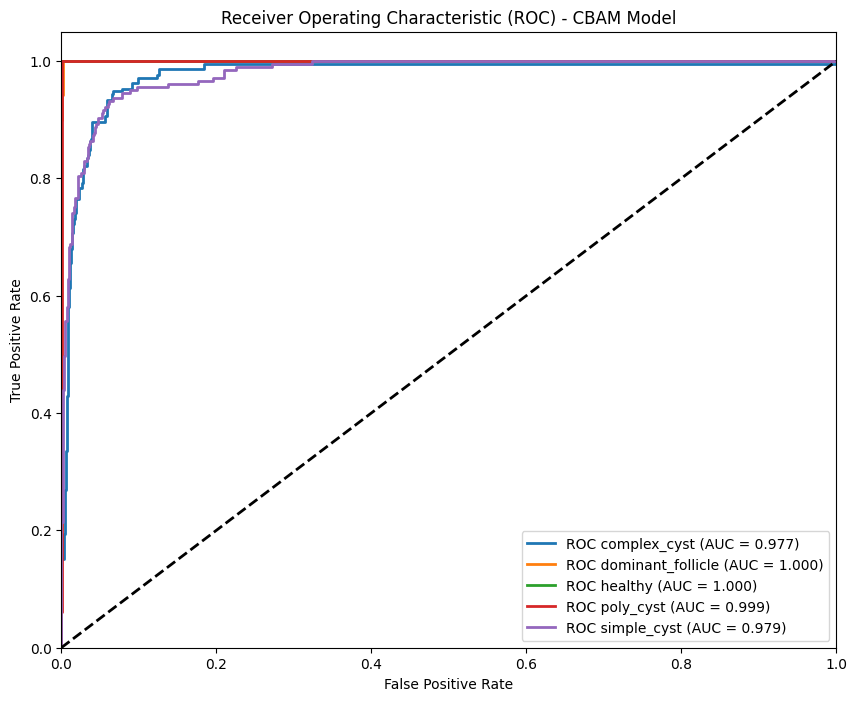

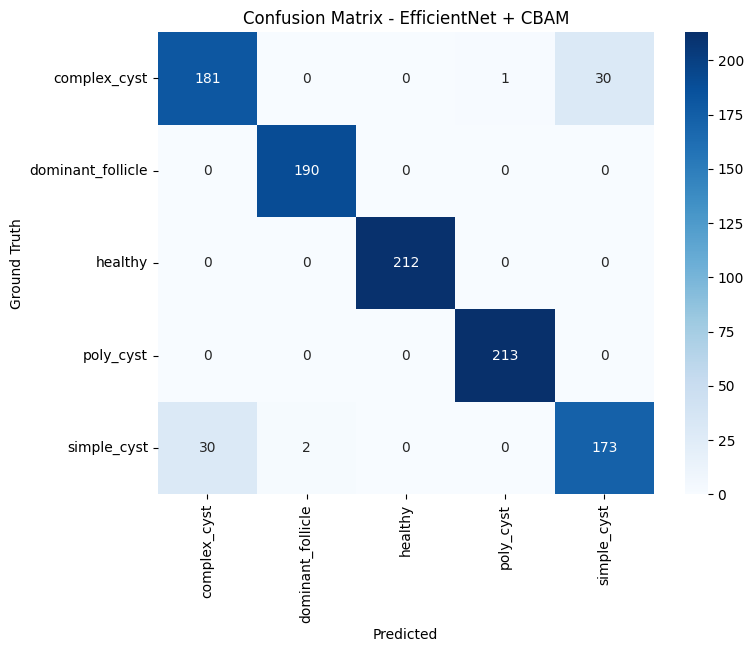

In [10]:
def evaluate_on_test(model, name):
    model.eval()
    running_corrects = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    test_acc = (running_corrects.double() / len(test_loader.sampler)).item()
    return test_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

test_acc_base, _, _, _ = evaluate_on_test(model_baseline, "Baseline")
test_acc_cbam, labels_cbam, preds_cbam, probs_cbam = evaluate_on_test(model_cbam, "CBAM")

print("="*40)
print("ACCURACY COMPARISON (Before vs After Attention)")
print("="*40)
print(f"WITHOUT ATTENTION (Baseline):")
print(f" - Train Acc: {history_base['train_acc'][-1]:.4f}")
print(f" - Val   Acc: {val_acc_base:.4f}")
print(f" - Test  Acc: {test_acc_base:.4f}\n")

print(f"WITH CBAM ATTENTION:")
print(f" - Train Acc: {history_cbam['train_acc'][-1]:.4f}")
print(f" - Val   Acc: {val_acc_cbam:.4f}")
print(f" - Test  Acc: {test_acc_cbam:.4f}")
print("="*40)

plt.figure(figsize=(10, 5))
plt.plot(history_base['val_acc'], label='Val Acc (Without Attention)', linestyle='--', color='red')
plt.plot(history_cbam['val_acc'], label='Val Acc (With CBAM Attention)', linewidth=2.5, color='blue')
plt.title('Validation Accuracy: Baseline vs CBAM Module')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Multiclass ROC & AUC
y_bin = label_binarize(labels_cbam, classes=[0,1,2,3,4])

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_cbam[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - CBAM Model')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(labels_cbam, preds_cbam)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Confusion Matrix - EfficientNet + CBAM')
plt.show()

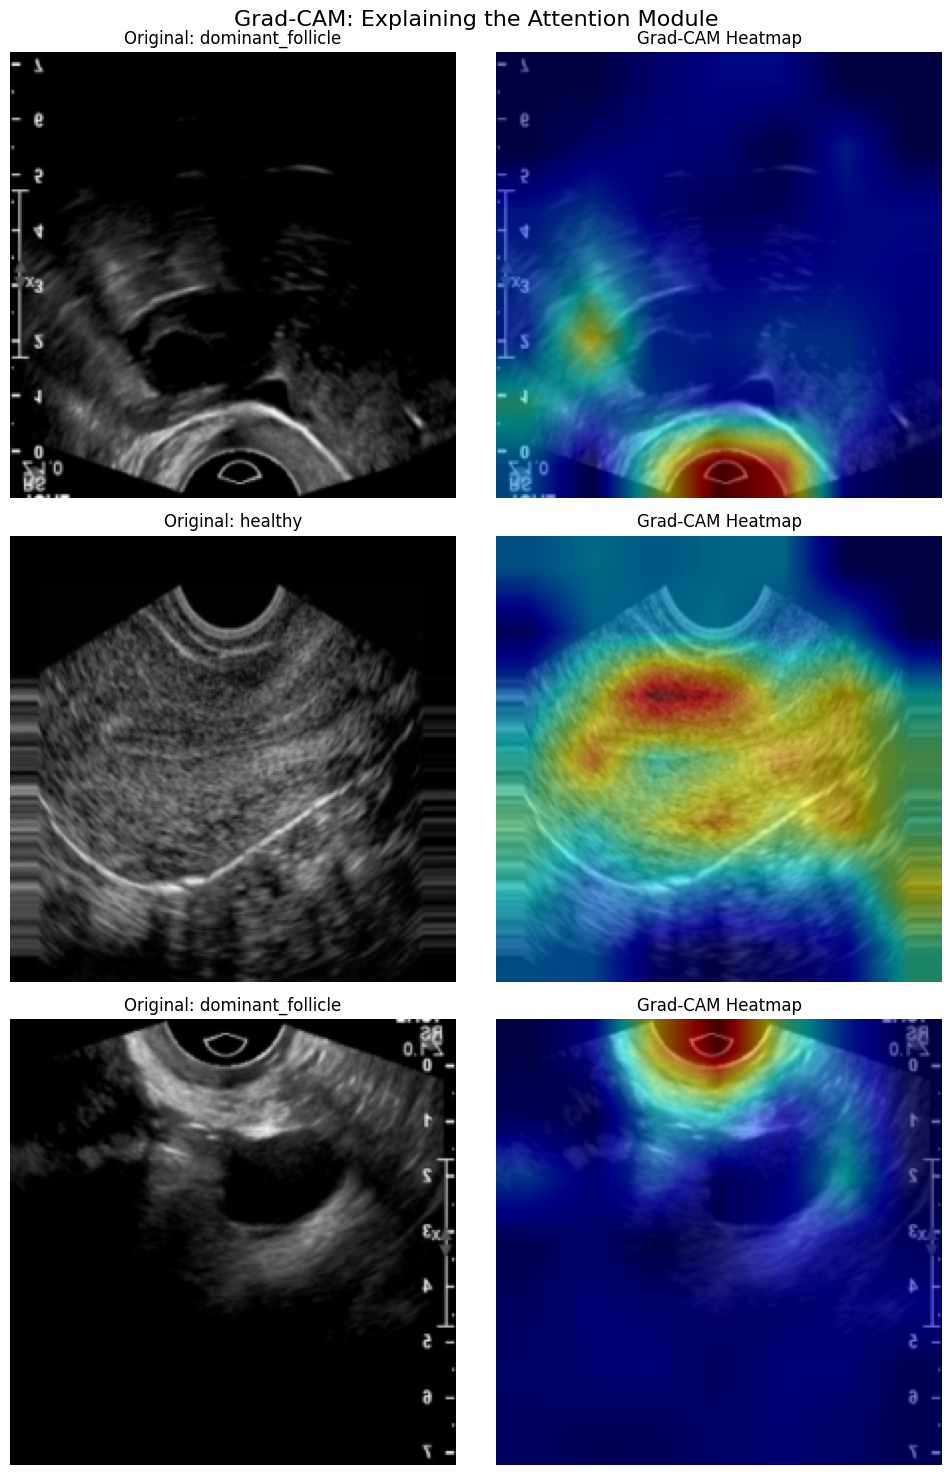

In [11]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model_cbam.cbam]
cam = GradCAM(model=model_cbam, target_layers=target_layers)

inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
fig.suptitle('Grad-CAM: Explaining the Attention Module', fontsize=16)

for i in range(3):
    input_tensor = inputs[i].unsqueeze(0)
    target_class = labels[i].item()
    
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    
    img_tensor = inputs[i].cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    rgb_img = img_tensor * std + mean
    rgb_img = np.clip(rgb_img.numpy().transpose(1, 2, 0), 0, 1)
    
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"Original: {class_names[target_class]}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(visualization)
    axes[i, 1].set_title("Grad-CAM Heatmap")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

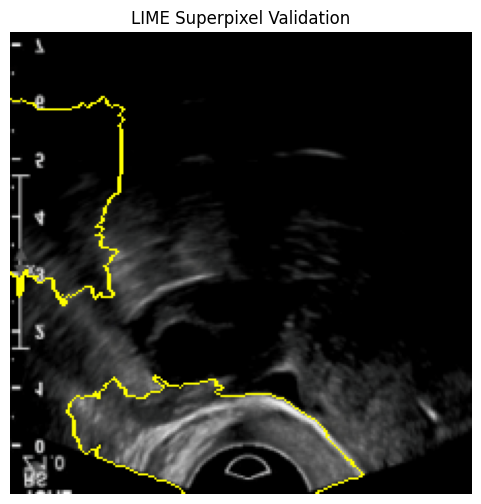

In [12]:
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def batch_predict(images):
    model_cbam.eval()
    batch = torch.stack([test_transforms(Image.fromarray(i)) for i in images], dim=0)
    batch = batch.to(device)
    with torch.no_grad():
        outputs = model_cbam(batch)
        probs = F.softmax(outputs, dim=1)
    return probs.cpu().numpy()

test_img_idx = 0
input_tensor = inputs[test_img_idx].cpu()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
rgb_img = input_tensor * std + mean
rgb_img = np.clip(rgb_img.numpy().transpose(1, 2, 0), 0, 1)
rgb_img_uint8 = (rgb_img * 255).astype(np.uint8)

explanation = explainer.explain_instance(
    rgb_img_uint8, 
    batch_predict, 
    top_labels=1, 
    hide_color=0, 
    num_samples=500
)

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Superpixel Validation")
plt.axis('off')
plt.show()

In [13]:
!pip install timm


In [14]:
import torch
import torch.nn as nn
import timm

class SwinTransformerClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(SwinTransformerClassifier, self).__init__()
        
        # Load the pretrained Swin-Base
        self.backbone = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=num_classes)
        
        # 1. Freeze EVERYTHING
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze ONLY the final classification head
        for param in self.backbone.head.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

# Ensure device is defined (if you haven't run previous cells in this session)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the Transformer onto the GPU
model_swin = SwinTransformerClassifier(num_classes=num_classes).to(device)

# Print the architecture summary
from torchinfo import summary
summary(model_swin, input_size=(1, 3, 224, 224))


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Layer (type:depth-idx)                                  Output Shape              Param #
SwinTransformerClassifier                               [1, 5]                    --
├─SwinTransformer: 1-1                                  [1, 5]                    --
│    └─PatchEmbed: 2-1                                  [1, 56, 56, 128]          --
│    │    └─Conv2d: 3-1                                 [1, 128, 56, 56]          (6,272)
│    │    └─LayerNorm: 3-2                              [1, 56, 56, 128]          (256)
│    └─Sequential: 2-2                                  [1, 7, 7, 1024]           --
│    │    └─SwinTransformerStage: 3-3                   [1, 56, 56, 128]          (397,896)
│    │    └─SwinTransformerStage: 3-4                   [1, 28, 28, 256]          (1,714,320)
│    │    └─SwinTransformerStage: 3-5                   [1, 14, 14, 512]          (57,317,920)
│    │    └─SwinTransformerStage: 3-6                   [1, 7, 7, 1024]           (27,304,512)
│    └─LayerNorm

In [15]:
# Train the Swin Transformer using our existing 15-epoch loop function
history_swin, val_acc_swin = train_model(model_swin, "Swin Transformer (Shifted Window Attention)")



--- Training Swin Transformer (Shifted Window Attention) ---
Epoch 1/15 | Val Acc: 0.9486 | Val Loss: 0.1955
Epoch 2/15 | Val Acc: 0.9602 | Val Loss: 0.1405
Epoch 3/15 | Val Acc: 0.9467 | Val Loss: 0.1342
Epoch 4/15 | Val Acc: 0.9583 | Val Loss: 0.1132
Epoch 5/15 | Val Acc: 0.9651 | Val Loss: 0.0998
Epoch 6/15 | Val Acc: 0.9680 | Val Loss: 0.0924
Epoch 7/15 | Val Acc: 0.9670 | Val Loss: 0.0881
Epoch 8/15 | Val Acc: 0.9670 | Val Loss: 0.0856
Epoch 9/15 | Val Acc: 0.9758 | Val Loss: 0.0831
Epoch 10/15 | Val Acc: 0.9796 | Val Loss: 0.0855
Epoch 11/15 | Val Acc: 0.9796 | Val Loss: 0.0806
Epoch 12/15 | Val Acc: 0.9719 | Val Loss: 0.0797
Epoch 13/15 | Val Acc: 0.9816 | Val Loss: 0.0795
Epoch 14/15 | Val Acc: 0.9777 | Val Loss: 0.0786
Epoch 15/15 | Val Acc: 0.9777 | Val Loss: 0.0785
-> Best Swin Transformer (Shifted Window Attention) Val Acc: 0.9816


FINAL ACCURACY SHOWDOWN (CNN vs TRANSFORMER)
1. EfficientNet Baseline: 0.9457 Test Acc
2. EfficientNet + CBAM:   0.9390 Test Acc
3. SWIN TRANSFORMER:      0.9767 Test Acc


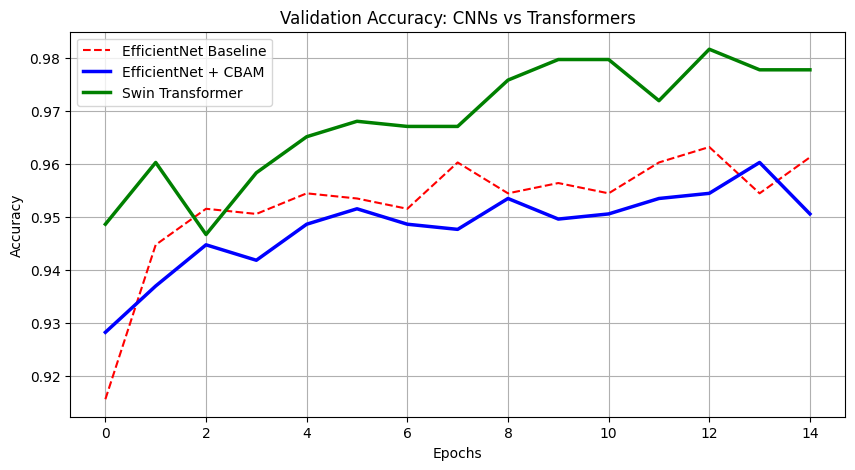

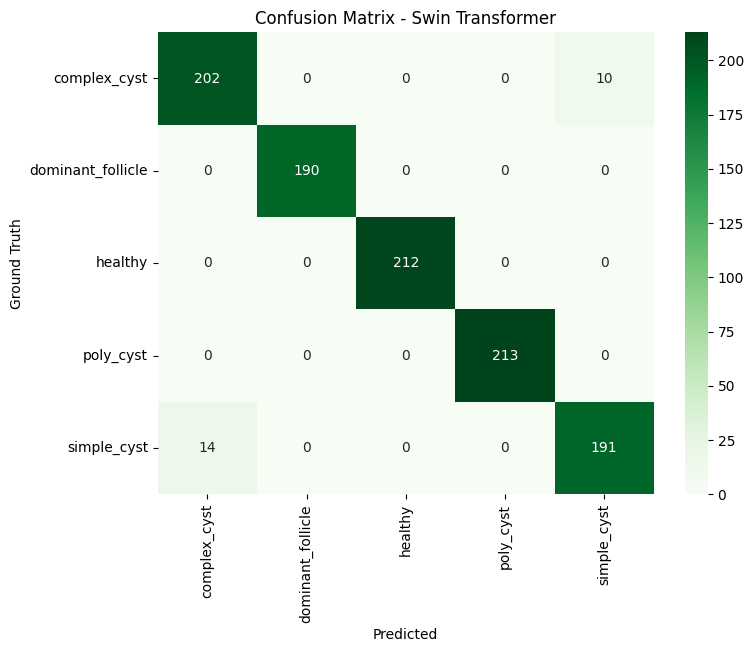

In [16]:
test_acc_swin, labels_swin, preds_swin, probs_swin = evaluate_on_test(model_swin, "Swin Transformer")

print("="*50)
print("FINAL ACCURACY SHOWDOWN (CNN vs TRANSFORMER)")
print("="*50)

print(f"1. EfficientNet Baseline: {test_acc_base:.4f} Test Acc")
print(f"2. EfficientNet + CBAM:   {test_acc_cbam:.4f} Test Acc")
print(f"3. SWIN TRANSFORMER:      {test_acc_swin:.4f} Test Acc")

# Compare Learning Curves Graph
plt.figure(figsize=(10, 5))
plt.plot(history_base['val_acc'], label='EfficientNet Baseline', linestyle='--', color='red')
plt.plot(history_cbam['val_acc'], label='EfficientNet + CBAM', linewidth=2.5, color='blue')
plt.plot(history_swin['val_acc'], label='Swin Transformer', linewidth=2.5, color='green')
plt.title('Validation Accuracy: CNNs vs Transformers')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Show where the Swin Transformer made mistakes
cm_swin = confusion_matrix(labels_swin, preds_swin)
plt.figure(figsize=(8,6))
sns.heatmap(cm_swin, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Confusion Matrix - Swin Transformer')
plt.show()


In [17]:
!pip install open_clip_torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00


In [19]:
import open_clip
from PIL import Image
from tqdm import tqdm

# 1. Load BiomedCLIP (Fixed Model ID)
model_clip, _, preprocess_val = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
tokenizer = open_clip.get_tokenizer("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
model_clip = model_clip.to(device)
model_clip.eval()

# 2. Zero-Shot Prompts
prompts = [f"an ovarian ultrasound of {name.replace('_', ' ')}" for name in class_names]
text_tokens = tokenizer(prompts).to(device)

# 3. Predict
all_labels, all_preds = [], []
with torch.no_grad():
    for idx in tqdm(test_idx, desc="Evaluating BiomedCLIP"):
        img_path, label = full_dataset.imgs[idx]
        image = Image.open(img_path).convert("RGB")
        image_input = preprocess_val(image).unsqueeze(0).to(device)
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text_tokens)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        all_preds.append(similarity[0].argmax().item())
        all_labels.append(label)

clip_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nBIOMED-CLIP ZERO-SHOT ACCURACY: {clip_acc:.4f}")


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Evaluating BiomedCLIP: 100%|██████████| 1032/1032 [01:43<00:00,  9.98it/s]


BIOMED-CLIP ZERO-SHOT ACCURACY: 0.3266


In [20]:
# 1. Define Hybrid Model
class MaxViTClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(MaxViTClassifier, self).__init__()
        self.backbone = timm.create_model('maxvit_tiny_tf_224', pretrained=True, num_classes=num_classes)
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.head.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

model_maxvit = MaxViTClassifier(num_classes=num_classes).to(device)

# 2. Train and Evaluate
history_maxvit, val_acc_maxvit = train_model(model_maxvit, "MaxViT Hybrid")
test_acc_maxvit, _, _, _ = evaluate_on_test(model_maxvit, "MaxViT")


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]


--- Training MaxViT Hybrid ---
Epoch 1/15 | Val Acc: 0.9467 | Val Loss: 0.1363
Epoch 2/15 | Val Acc: 0.9370 | Val Loss: 0.1346
Epoch 3/15 | Val Acc: 0.9505 | Val Loss: 0.1298
Epoch 4/15 | Val Acc: 0.9515 | Val Loss: 0.1059
Epoch 5/15 | Val Acc: 0.9515 | Val Loss: 0.1271
Epoch 6/15 | Val Acc: 0.9583 | Val Loss: 0.1179
Epoch 7/15 | Val Acc: 0.9622 | Val Loss: 0.0907
Epoch 8/15 | Val Acc: 0.9612 | Val Loss: 0.0797
Epoch 9/15 | Val Acc: 0.9670 | Val Loss: 0.0742
Epoch 10/15 | Val Acc: 0.9690 | Val Loss: 0.0701
Epoch 11/15 | Val Acc: 0.9690 | Val Loss: 0.0683
Epoch 12/15 | Val Acc: 0.9699 | Val Loss: 0.0785
Epoch 13/15 | Val Acc: 0.9728 | Val Loss: 0.0657
Epoch 14/15 | Val Acc: 0.9719 | Val Loss: 0.0685
Epoch 15/15 | Val Acc: 0.9690 | Val Loss: 0.0679
-> Best MaxViT Hybrid Val Acc: 0.9728


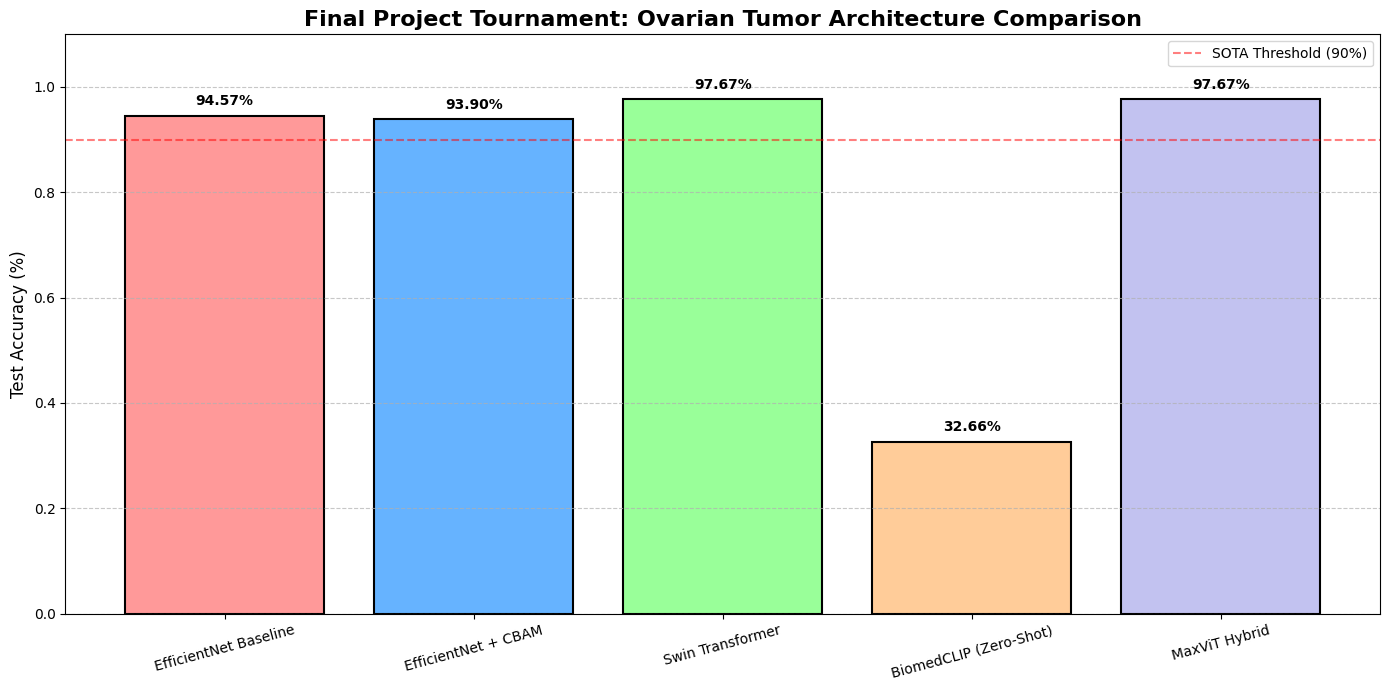


The Overall Winner is: Swin Transformer!


In [21]:
methods = ['EfficientNet Baseline', 'EfficientNet + CBAM', 'Swin Transformer', 'BiomedCLIP (Zero-Shot)', 'MaxViT Hybrid']
accuracies = [test_acc_base, test_acc_cbam, test_acc_swin, clip_acc, test_acc_maxvit]

plt.figure(figsize=(14, 7))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.5)

plt.ylim(0, 1.1)
plt.title('Final Project Tournament: Ovarian Tumor Architecture Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.2f}%', ha='center', fontweight='bold')

plt.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='SOTA Threshold (90%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nThe Overall Winner is: {methods[np.argmax(accuracies)]}!")
